> **Note (superseded):** the overall score reported in this notebook (~0.567) is *exploratory only* and is **superseded by `results/baseline.json` (overall 0.6288)**, the single source of truth. Numbers here may use a different sample or scoring shortcut.

# Failure Mode Analysis

## Setup

In [ ]:
!pip install pandas openpyxl sentence-transformers spacy word2number nltk tqdm scikit-learn
!python -m spacy download en_core_web_sm

In [30]:
import sys
from pathlib import Path

REPO = Path("~/Desktop/Research & Projects/ucsf_agent/kaggle-cohort-x-task-1-solution").expanduser().resolve()

assert (REPO / "evaluate.py").exists()
assert (REPO / "config.py").exists()
assert (REPO / "parser.py").exists()

sys.path.insert(0, str(REPO))

from common.evaluate import evaluate_fast
from common.parser import NXMLParser
from local_llm.predict_qwen import get_relevant_sections, build_prompt

In [2]:
PRED_PATH = Path(".") / 'ver 3 (rag)' / 'submission_qwen3_4b_8bit_colab.xlsx'
DATA_DIR = Path.home() / 'Downloads' / 'cohort-x-task-1'
NXML_DIR = DATA_DIR / 'PMC_NXML_Archives'

In [3]:
import pandas as pd

In [4]:
preds_df = pd.read_excel(PRED_PATH)

task_df = pd.read_excel(DATA_DIR / 'Task_1.xlsx', sheet_name='Train')

FIELDS = [
    "conditions",
    "study_type",
    "sex",
    "minimum_age",
    "maximum_age",
    "eligibility_criteria",
]

gold_df = task_df[["pmcids"] + FIELDS].copy()

preds_df["pmcids"] = preds_df["pmcids"].astype(str).str.strip()
gold_df["pmcids"] = gold_df["pmcids"].astype(str).str.strip()

preds_df.head()

,conditions,study_type,sex,minimum_age,maximum_age,eligibility_criteria,pmcids
0,"['cerebral amyloid angiopathy', 'intracerebral...",OBSERVATIONAL,FEMALE,65,65,Inclusion Criteria: [patient with acute ischem...,12279614
1,"['mental illness', 'suicide']",OBSERVATIONAL,ALL,Not Specified,Not Specified,Inclusion Criteria: [service members and veter...,12108871
2,['oncology'],OBSERVATIONAL,ALL,Not Specified,Not Specified,Inclusion Criteria: [none specified]; Exclusio...,12300555
3,"['Intracranial haemorrhage', 'Hypodensities su...",INTERVENTIONAL,ALL,18 years,Not Specified,Inclusion Criteria: *Aged 18 years or above; *...,10862304
4,"['hematological disorders', 'HIV', 'SARS-CoV-2...",OBSERVATIONAL,ALL,Not Specified,Not Specified,Inclusion Criteria: [patients with immunocompr...,12470843


In [5]:
print("Prediction columns:")
print(preds_df.columns.tolist())

print("\nGold columns:")
print(gold_df.columns.tolist())

missing_pred_cols = [c for c in ["pmcids"] + FIELDS if c not in preds_df.columns]
missing_gold_cols = [c for c in ["pmcids"] + FIELDS if c not in gold_df.columns]

assert not missing_pred_cols, f"Missing columns in preds_df: {missing_pred_cols}"
assert not missing_gold_cols, f"Missing columns in gold_df: {missing_gold_cols}"

print(f"\nPred rows: {len(preds_df)}")
print(f"Gold rows: {len(gold_df)}")

Prediction columns:
['conditions', 'study_type', 'sex', 'minimum_age', 'maximum_age', 'eligibility_criteria', 'pmcids']

Gold columns:
['pmcids', 'conditions', 'study_type', 'sex', 'minimum_age', 'maximum_age', 'eligibility_criteria']

Pred rows: 416
Gold rows: 416


In [6]:
scores_df = evaluate_fast(preds_df, gold_df)

scores_df.head()

Encoding with BioBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]


=== Mean Scores ===
  conditions               : 0.6208
  study_type               : 0.6676
  sex                      : 1.0000
  minimum_age              : 0.2356
  maximum_age              : 0.5601
  eligibility_criteria     : 0.5549
  overall                  : 0.5669


,conditions,study_type,eligibility_criteria,sex,minimum_age,maximum_age,overall
0,0.905807,0.670307,0.574701,1.0,0.0,0.0,0.540252
1,0.265820,0.442558,0.245268,1.0,0.0,1.0,0.356763
2,0.386676,0.510427,0.242350,1.0,0.0,1.0,0.380219
3,0.844535,0.496849,0.658464,1.0,0.0,1.0,0.655597
4,0.530341,0.434576,0.591048,1.0,0.0,1.0,0.568533


## Helper Functions

In [7]:
def print_worst(
    pred_df,
    gold_df,
    target="overall",
    scores_df=None,
    id_col="pmcids",
    k=10,
    max_chars=2000,
):
    """
    Print worst examples by either:
      - target="overall"
      - target=<specific field>

    Example:
        print_worst(preds_df, gold_df, target="overall", k=5)
        print_worst(preds_df, gold_df, target="eligibility_criteria", k=10)

    The printed PMC ID can be used with:
        print_nxml(<pmc_id>)
    """

    fields = [
        "conditions",
        "study_type",
        "sex",
        "minimum_age",
        "maximum_age",
        "eligibility_criteria",
    ]

    valid_targets = fields + ["overall"]

    if target not in valid_targets:
        raise ValueError(f"target must be one of {valid_targets}")

    pred = pred_df.copy()
    gold = gold_df.copy()

    pred[id_col] = pred[id_col].astype(str).str.strip()
    gold[id_col] = gold[id_col].astype(str).str.strip()

    if scores_df is None:
        scores_df = evaluate_fast(pred, gold)

    merged = pred.merge(
        gold,
        on=id_col,
        suffixes=("_pred", "_gold"),
        how="inner",
    ).reset_index(drop=True)

    scores_df = scores_df.reset_index(drop=True)

    if len(merged) != len(scores_df):
        raise ValueError(
            f"Length mismatch: merged has {len(merged)} rows, "
            f"but scores_df has {len(scores_df)} rows."
        )

    for col in fields + ["overall"]:
        if col in scores_df.columns:
            merged[f"{col}_score"] = scores_df[col].values

    sort_col = f"{target}_score"
    worst = merged.sort_values(sort_col, ascending=True).head(k)

    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        pmc_id = str(row[id_col])

        print("=" * 120)
        print(f"Rank: {rank}")
        print(f"PMC ID: {pmc_id}")
        print(f"To inspect full article: print_nxml('{pmc_id}')")
        print(f"Target: {target}")
        print(f"Target score: {row[sort_col]:.4f}")
        print(f"Failure score: {1 - row[sort_col]:.4f}")

        print("\nField scores:")
        for f in fields:
            score_col = f"{f}_score"
            if score_col in row:
                print(f"  {f:22s}: {row[score_col]:.4f}")

        if target == "overall":
            shown_fields = fields
        else:
            shown_fields = [target]

        print("\nPrediction vs Gold:")
        for f in shown_fields:
            pred_value = str(row.get(f"{f}_pred", ""))
            gold_value = str(row.get(f"{f}_gold", ""))

            if len(pred_value) > max_chars:
                pred_value = pred_value[:max_chars] + "\n... [truncated]"

            if len(gold_value) > max_chars:
                gold_value = gold_value[:max_chars] + "\n... [truncated]"

            print("-" * 120)
            print(f"[{f}]")
            print("\nPRED:")
            print(pred_value)
            print("\nGOLD:")
            print(gold_value)

        print()

    return worst

In [13]:
parser = NXMLParser()

def print_nxml(
    pmc_id,
    nxml_dir=NXML_DIR,
    max_chars=None,
):
    """
    Pretty-print an article using the project's NXMLParser.

    Args:
        pmc_id: PMC ID, with or without the 'PMC' prefix.
        nxml_dir: Root directory containing the PMC NXML archive.
        max_chars:
            None -> print everything.
            int  -> truncate each section to that many characters.

    Returns:
        Parsed article dictionary.
    """

    pmc_id = str(pmc_id).strip().replace("PMC", "")
    nxml_dir = Path(nxml_dir)

    candidates = [
        nxml_dir / f"PMC{pmc_id}.nxml",
        nxml_dir / f"{pmc_id}.nxml",
        nxml_dir / f"PMC{pmc_id}.xml",
        nxml_dir / f"{pmc_id}.xml",
    ]

    path = next((p for p in candidates if p.exists()), None)

    if path is None:
        matches = (
            list(nxml_dir.rglob(f"*{pmc_id}*.nxml"))
            + list(nxml_dir.rglob(f"*{pmc_id}*.xml"))
        )
        if matches:
            path = matches[0]

    if path is None:
        raise FileNotFoundError(f"Could not locate PMC{pmc_id}.")

    parsed = parser.parse(str(path))

    print("=" * 100)
    print(f"PMC ID : {pmc_id}")
    print(f"FILE   : {path}")
    print("=" * 100)

    print("\nTITLE")
    print("-" * 100)
    print(parsed.get("title", ""))

    print("\nABSTRACT")
    print("-" * 100)
    print(parsed.get("abstract", ""))

    keywords = parsed.get("keywords", [])
    if keywords:
        print("\nKEYWORDS")
        print("-" * 100)
        print("; ".join(keywords))

    sections = parsed.get("sections", [])

    print("\n")
    print("#" * 100)
    print(f"SECTIONS ({len(sections)})")
    print("#" * 100)

    for i, sec in enumerate(sections, start=1):
        title = sec.get("title", "Untitled")
        text = str(sec.get("text", ""))

        if max_chars is not None and len(text) > max_chars:
            text = text[:max_chars] + "\n... [truncated]"

        print("\n")
        print("=" * 100)
        print(f"[{i}] {title}")
        print("=" * 100)
        print(text)

    return parsed

def find_nxml(pmc_id, nxml_dir):
    pid = str(pmc_id).strip().replace("PMC", "")
    nxml_dir = Path(nxml_dir)

    candidates = [
        nxml_dir / f"PMC{pid}.nxml",
        nxml_dir / f"{pid}.nxml",
        nxml_dir / f"PMC{pid}.xml",
        nxml_dir / f"{pid}.xml",
    ]

    for p in candidates:
        if p.exists():
            return p

    matches = list(nxml_dir.rglob(f"*{pid}*.nxml")) + list(nxml_dir.rglob(f"*{pid}*.xml"))
    if matches:
        return matches[0]

    raise FileNotFoundError(f"Could not find NXML for PMC{pid}")

In [18]:
def print_llm_sections(pmc_id, nxml_dir=NXML_DIR, max_chars=None):
    """
    Print the exact relevant sections produced by repo get_relevant_sections().
    max_chars=None prints everything.
    """

    path = find_nxml(pmc_id, nxml_dir)
    parsed = parser.parse(str(path))

    context = get_relevant_sections(parsed)

    shown = context
    if max_chars is not None and len(shown) > max_chars:
        shown = shown[:max_chars] + "\n... [truncated]"

    print("=" * 100)
    print(f"PMC ID: {str(pmc_id).replace('PMC', '')}")
    print(f"NXML: {path}")
    print(f"Context chars: {len(context)}")
    print("=" * 100)
    print(shown)

    return context, parsed

In [19]:
def print_llm_prompt(pmc_id, nxml_dir=NXML_DIR, max_chars=None):
    """
    Print the exact prompt produced by repo build_prompt().
    max_chars=None prints everything.
    """

    path = find_nxml(pmc_id, nxml_dir)
    parsed = parser.parse(str(path))

    prompt = build_prompt(parsed)

    shown = prompt
    if max_chars is not None and len(shown) > max_chars:
        shown = shown[:max_chars] + "\n... [truncated]"

    print("=" * 100)
    print(f"PMC ID: {str(pmc_id).replace('PMC', '')}")
    print(f"NXML: {path}")
    print(f"Prompt chars: {len(prompt)}")
    print("=" * 100)
    print(shown)

    return prompt, parsed

In [27]:
# body, selected = print_llm_sections("12630228")
# prompt = print_llm_prompt("12630228")

## Diagnosis

### Field: ```Eligibility_Criteria```

In [52]:
worst_eligibility = print_worst(
    preds_df,
    gold_df,
    target="eligibility_criteria",
    scores_df=scores_df,
    k=50,
)

Rank: 1
PMC ID: 12360625
To inspect full article: print_nxml('12360625')
Target: eligibility_criteria
Target score: 0.0421
Failure score: 0.9579

Field scores:
  conditions            : 0.1171
  study_type            : 0.2454
  sex                   : 1.0000
  minimum_age           : 0.0000
  maximum_age           : 0.0000
  eligibility_criteria  : 0.0421

Prediction vs Gold:
------------------------------------------------------------------------------------------------------------------------
[eligibility_criteria]

PRED:
Not Specified

GOLD:
GTS Group:

Inclusion Criteria:

* GTS according to DSM-IV-TR criteria
* mild or moderate tics
* drug-free for a minimum of 4 weeks prior to the exam

Exclusion Criteria:

* severe tics of the head and/or face
* psychiatric medication within 4 weeks prior to the exam
* consumption of alcohol during 24 hours prior to the exam
* consumption of cannabis during 24 hours prior to the exam • pregnancy
* general contra-indications for MRI exams

Contro

### Field: ```Conditions```

In [24]:
worst_conditions = print_worst(
    preds_df,
    gold_df,
    target="conditions",
    scores_df=scores_df,
    k=5,
)

Rank: 1
PMC ID: 11465069
To inspect full article: print_nxml('11465069')
Target: conditions
Target score: 0.0173
Failure score: 0.9827

Field scores:
  conditions            : 0.0173
  study_type            : 0.3689
  sex                   : 1.0000
  minimum_age           : 0.0000
  maximum_age           : 1.0000
  eligibility_criteria  : 0.0918

Prediction vs Gold:
------------------------------------------------------------------------------------------------------------------------
[conditions]

PRED:
['Not Specified']

GOLD:
['Contrast Media Dosing']

Rank: 2
PMC ID: 10933246
To inspect full article: print_nxml('10933246')
Target: conditions
Target score: 0.0264
Failure score: 0.9736

Field scores:
  conditions            : 0.0264
  study_type            : 0.7673
  sex                   : 1.0000
  minimum_age           : 0.0000
  maximum_age           : 0.0000
  eligibility_criteria  : 0.3856

Prediction vs Gold:
---------------------------------------------------------------------

### Field: Overall

In [25]:
worst_overall = print_worst(
    preds_df,
    gold_df,
    target="overall",
    scores_df=scores_df,
    k=5,
)

Rank: 1
PMC ID: 12360625
To inspect full article: print_nxml('12360625')
Target: overall
Target score: 0.1132
Failure score: 0.8868

Field scores:
  conditions            : 0.1171
  study_type            : 0.2454
  sex                   : 1.0000
  minimum_age           : 0.0000
  maximum_age           : 0.0000
  eligibility_criteria  : 0.0421

Prediction vs Gold:
------------------------------------------------------------------------------------------------------------------------
[conditions]

PRED:
['Not Specified']

GOLD:
['Gilles de la Tourette Syndrome', 'Tourette Syndrome']
------------------------------------------------------------------------------------------------------------------------
[study_type]

PRED:
Not Specified

GOLD:
OBSERVATIONAL
------------------------------------------------------------------------------------------------------------------------
[sex]

PRED:
Not Specified

GOLD:
ALL
-----------------------------------------------------------------------------

### Inspecting ...

In [31]:
prompt = print_llm_prompt('12360625')

PMC ID: 12360625
NXML: /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC12360625.nxml
Prompt chars: 2152
You are a biomedical information extraction system. Read the following article and extract the requested fields.

Article:
Title: Dopamine Receptor 1 Specific CRISPRa Mice Exhibit Disrupted Behaviors and Striatal Baseline Cellular Activity

Abstract: The two main cell types in the striatum, dopamine receptor 1 and adenosine receptor 2a spiny projection neurons (D1-SPNs and A2A-SPNs), have distinct roles in regulating motor- and reward-related behaviors. Cre-selective CRISPR-dCas9 systems allow for cell-type specific, epigenomic-based manipulation of gene expression with gene-specific single guide RNAs (sgRNAs) and have potential to elucidate molecular mechanisms underlying striatal subtype mediated behaviors. Conditional transgenic Rosa26:LSL-dCas9-p300 mice were recently generated to allow for robust expression of dCas9-p300 expression wi

Keywords: CRISPR activation,

In [54]:
print_nxml('12623346')

PMC ID : 12623346
FILE   : /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC12623346.nxml

TITLE
----------------------------------------------------------------------------------------------------
Bispecific immunotherapy based on antibodies, T-cell receptors, and aptamers: mechanisms of action, adverse effects, and future perspectives

ABSTRACT
----------------------------------------------------------------------------------------------------
Over the past decade, bispecific immunotherapeutic platforms have progressed from laboratory prototypes to multicenter clinical trials, inaugurating a new trajectory for precision oncology. This review synthesizes original studies that address the design principles, mechanisms of action, therapeutic efficacy, and limitations of three principal classes of bispecific molecules: (i) IgG-like antibodies, (ii) modified T-cell-receptor-based constructs (TCR-like and ImmTAC), and (iii) bispecific aptamers. IgG formats—including blinatumo

{'title': 'Bispecific immunotherapy based on antibodies, T-cell receptors, and aptamers: mechanisms of action, adverse effects, and future perspectives',
 'abstract': 'Over the past decade, bispecific immunotherapeutic platforms have progressed from laboratory prototypes to multicenter clinical trials, inaugurating a new trajectory for precision oncology. This review synthesizes original studies that address the design principles, mechanisms of action, therapeutic efficacy, and limitations of three principal classes of bispecific molecules: (i) IgG-like antibodies, (ii) modified T-cell-receptor-based constructs (TCR-like and ImmTAC), and (iii) bispecific aptamers. IgG formats—including blinatumomab, teclistamab, mosunetuzumab, and tarlatamab—achieve high objective-response rates in hematologic malignancies and are increasingly demonstrating clinical activity in solid tumors. TCR-based constructs broaden the repertoire of actionable targets by recognizing intracellular antigens presente

### Section Relevance

In [38]:
from sentence_transformers import SentenceTransformer, util

ranker = SentenceTransformer("all-MiniLM-L6-v2")

QUERY = (
    "inclusion exclusion eligibility criteria study participants enrollment "
    "were eligible were excluded met criteria patients enrolled "
    "age sex gender minimum maximum demographic restrictions "
    "aged years old male female adult pediatric "
    "required diagnosis clinical conditions prior history comorbidities "
    "contraindications disqualifying factors "
    "study design randomized controlled trial observational prospective "
    "retrospective interventional cohort participants recruited "
    "disease condition disorder diagnosis primary secondary treated patients"
)

query_emb = ranker.encode(QUERY, convert_to_tensor=True)

def print_section_relevance(
    pmc_id,
    nxml_dir=NXML_DIR,
    threshold=None,
):
    """
    Inspect MiniLM relevance scores for every section.

    Parameters
    ----------
    pmc_id : str
    nxml_dir : Path
    threshold : float or None
        Only print sections with score >= threshold.
        None prints every section.

    Returns
    -------
    scored : list
        Sorted list of section dictionaries.
    parsed : dict
        Parsed article.
    """

    path = find_nxml(pmc_id, nxml_dir)
    parsed = parser.parse(str(path))

    sections = parsed.get("sections", [])

    print("=" * 100)
    print(f"PMC{pmc_id}")
    print(parsed.get("title", ""))
    print(f"Sections: {len(sections)}")
    print("=" * 100)

    scored = []

    for idx, sec in enumerate(sections):

        title = sec.get("title", "")
        body = sec.get("text", "")
        snippet = body

        title_emb = ranker.encode(title, convert_to_tensor=True)
        text_emb = ranker.encode(snippet, convert_to_tensor=True)

        title_score = float(util.cos_sim(query_emb, title_emb))
        text_score = float(util.cos_sim(query_emb, text_emb))
        score = max(title_score, text_score)

        scored.append({
            "idx": idx,
            "title": title,
            "title_score": title_score,
            "text_score": text_score,
            "score": score,
            "chars": len(body),
            "section": sec,
        })

    scored.sort(key=lambda x: x["score"], reverse=True)

    if threshold is not None:
        scored = [s for s in scored if s["score"] >= threshold]

    print(
        f"{'Rank':<5}"
        f"{'Score':>8}"
        f"{'Title':>8}"
        f"{'Body':>8}   "
        f"Section"
    )
    print("-" * 110)

    for rank, s in enumerate(scored, start=1):
        print(
            f"{rank:<5}"
            f"{s['score']:>8.3f}"
            f"{s['title_score']:>8.3f}"
            f"{s['text_score']:>8.3f}   "
            f"[{s['idx']:02d}] {s['title']}"
        )

    return scored, parsed

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [53]:
scores, parsed = print_section_relevance(
    '12623346',
    threshold=0,
)

PMC12623346
Bispecific immunotherapy based on antibodies, T-cell receptors, and aptamers: mechanisms of action, adverse effects, and future perspectives
Sections: 31
Rank    Score   Title    Body   Section
--------------------------------------------------------------------------------------------------------------
1       0.279   0.279   0.028   [08] Preclinical and clinical examples
2       0.178   0.178   0.030   [23] Combinations with immune checkpoint inhibitors
3       0.167   0.121   0.167   [22] Combinations with cellular therapies
4       0.158   0.046   0.158   [28] Conflict of interest
5       0.158   0.158  -0.060   [16] Adverse effects and limitations of bispecific therapy
6       0.156   0.156   0.105   [05] Clinical applications and future perspectives of bispecific antibodies
7       0.145   0.145   0.064   [10] Clinical differences between TCR-like/TCR-engineered and conventional bispecific antibodies
8       0.135   0.135   0.126   [20] Immunogenicity and anti-drug an

In [ ]:
print(scores[0]["section"]["text"])

In [44]:
from pathlib import Path
import numpy as np
from tqdm import tqdm

parser = NXMLParser()

lengths = []

for pmc_id in tqdm(task_df["pmcids"]):

    path = find_nxml(str(pmc_id), NXML_DIR)
    parsed = parser.parse(str(path))

    text = (
        parsed.get("title", "")
        + parsed.get("abstract", "")
        + "".join(sec.get("text", "") for sec in parsed.get("sections", []))
    )

    lengths.append(len(text))

lengths = np.array(lengths)

print(f"Training articles: {len(lengths)}")
print(f"Mean   : {lengths.mean():.0f}")
print(f"Median : {np.median(lengths):.0f}")
print(f"Min    : {lengths.min()}")
print(f"Max    : {lengths.max()}")

for p in [50, 75, 90, 95, 99]:
    print(f"P{p:<2}: {np.percentile(lengths, p):.0f}")

100%|█████████████████████████████████████████| 416/416 [00:00<00:00, 488.60it/s]

Training articles: 416
Mean   : 34203
Median : 29752
Min    : 36
Max    : 331067
P50: 29752
P75: 39000
P90: 52240
P95: 62255
P99: 99393


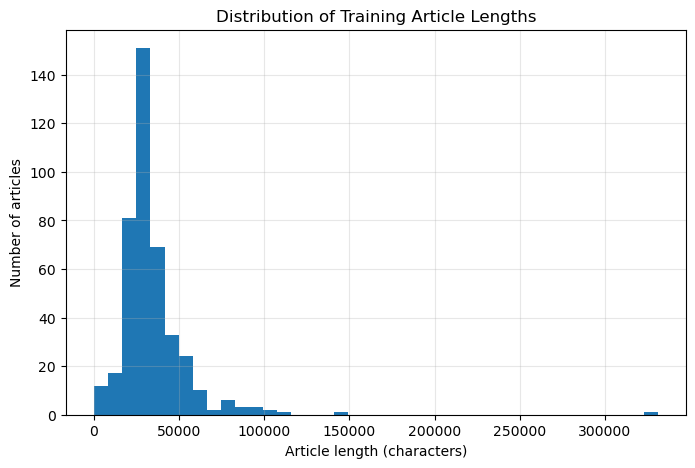

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=40)
plt.xlabel("Article length (characters)")
plt.ylabel("Number of articles")
plt.title("Distribution of Training Article Lengths")
plt.grid(alpha=0.3)

plt.show()

In [49]:
HARD_CAP = 20_000
RATIO = 0.50

rows = []

for pmc_id in tqdm(task_df["pmcids"].astype(str)):
    path = find_nxml(pmc_id, NXML_DIR)
    parsed = parser.parse(str(path))

    article_len = (
        len(parsed.get("title", ""))
        + len(parsed.get("abstract", ""))
        + sum(len(sec.get("text", "")) for sec in parsed.get("sections", []))
    )

    budget = article_len if article_len <= HARD_CAP else min(HARD_CAP, int(RATIO * article_len))

    rows.append((pmc_id, article_len, budget, budget / article_len if article_len else np.nan))

budget_df = pd.DataFrame(
    rows,
    columns=["pmcids", "article_len", "budget", "coverage"]
)

budget_df.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

100%|█████████████████████████████████████████| 416/416 [00:00<00:00, 514.29it/s]


,article_len,budget,coverage
count,416.000000,416.000000,416.000000
mean,34202.915865,15570.567308,0.527001
std,22226.707781,3779.064475,0.180242
min,36.000000,36.000000,0.060411
25%,24610.750000,12974.250000,0.499976
50%,29752.000000,15434.000000,0.499986
75%,39000.250000,19625.000000,0.500000
90%,52240.500000,20000.000000,1.000000
95%,62255.000000,20000.000000,1.000000
99%,99392.950000,20000.000000,1.000000


In [50]:
print("Full article count:", (budget_df["budget"] == budget_df["article_len"]).sum())
print("Capped count:", (budget_df["budget"] == HARD_CAP).sum())
print("Adaptive count:", ((budget_df["budget"] < HARD_CAP) & (budget_df["budget"] < budget_df["article_len"])).sum())

Full article count: 46
Capped count: 98
Adaptive count: 272


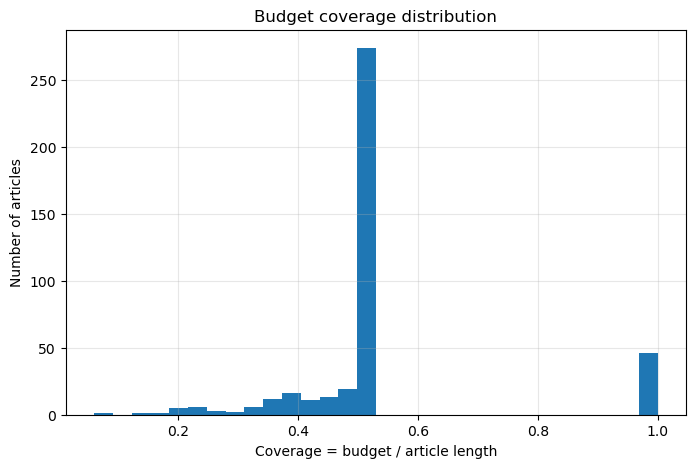

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(budget_df["coverage"], bins=30)
plt.xlabel("Coverage = budget / article length")
plt.ylabel("Number of articles")
plt.title("Budget coverage distribution")
plt.grid(alpha=0.3)
plt.show()

In [56]:
from sentence_transformers import SentenceTransformer, util

# Biomedical sentence embedding model
ranker = SentenceTransformer(
    "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb"
)

QUERY = (
    # Core eligibility and cohort selection
    "Inclusion criteria and exclusion criteria for study eligibility. "
    "Patients or participants were considered eligible for enrollment if they met the following criteria. "
    "Study population, participant selection, patient selection, screening, recruitment, and cohort enrollment. "
    "Patients were included if and excluded if. "

    # Demographic restrictions
    "Demographic restrictions including age, sex, gender, minimum age, maximum age, adult participants, "
    "pediatric participants, male participants, female participants, and subjects aged years old. "

    # Clinical qualification and baseline disease status
    "Confirmed clinical diagnosis of the primary disease, condition, disorder, cancer, tumor, infection, or syndrome. "
    "Clinical history, prior treatment history, previous therapy, comorbidities, disease stage, disease severity, "
    "baseline characteristics, and baseline clinical status. "

    # Contraindications and disqualifying factors
    "Disqualifying factors and contraindications including pregnancy, breastfeeding, renal impairment, "
    "hepatic impairment, organ failure, allergy, hypersensitivity, prior malignancy, active infection, "
    "immunosuppression, inability to provide informed consent, and withdrawal criteria."
)

query_emb = ranker.encode(QUERY, convert_to_tensor=True)

def print_section_relevance(
    pmc_id,
    nxml_dir=NXML_DIR,
    threshold=None,
):
    """
    Inspect BioBERT relevance scores for every section.

    Returns
    -------
    all_scored : list
        All sections sorted by relevance.
    parsed : dict
        Parsed article.
    """

    path = find_nxml(pmc_id, nxml_dir)
    parsed = parser.parse(str(path))
    sections = parsed.get("sections", [])

    print("=" * 100)
    print(f"PMC{pmc_id}")
    print(parsed.get("title", ""))
    print(f"Sections: {len(sections)}")
    print("=" * 100)

    scored = []

    for idx, sec in enumerate(sections):

        title = sec.get("title", "") or ""
        body = sec.get("text", "") or ""

        # BioBERT silently truncates long inputs.
        # Keep enough context while avoiding excessive sequence length.
        body_for_embedding = body[:4000]

        title_emb = ranker.encode(title, convert_to_tensor=True)
        body_emb = ranker.encode(body_for_embedding, convert_to_tensor=True)

        title_score = float(util.cos_sim(query_emb, title_emb).item())
        body_score = float(util.cos_sim(query_emb, body_emb).item())
        score = max(title_score, body_score)

        scored.append({
            "idx": idx,
            "title": title,
            "title_score": title_score,
            "body_score": body_score,
            "score": score,
            "chars": len(body),
            "section": sec,
        })

    all_scored = sorted(scored, key=lambda x: x["score"], reverse=True)

    if threshold is None:
        shown = all_scored
    else:
        shown = [s for s in all_scored if s["score"] >= threshold]

    print(
        f"{'Rank':<5}"
        f"{'Score':>8}"
        f"{'Title':>8}"
        f"{'Body':>8}"
        f"{'Chars':>10}   "
        f"Section"
    )
    print("-" * 120)

    for rank, s in enumerate(shown, start=1):
        print(
            f"{rank:<5}"
            f"{s['score']:>8.3f}"
            f"{s['title_score']:>8.3f}"
            f"{s['body_score']:>8.3f}"
            f"{s['chars']:>10}   "
            f"[{s['idx']:02d}] {s['title']}"
        )

    if threshold is not None and not shown:
        print(f"No sections passed threshold = {threshold:.3f}")

    return all_scored, parsed

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
scores, parsed = print_section_relevance(
    '12623346',
    threshold=0,
)

PMC12623346
Bispecific immunotherapy based on antibodies, T-cell receptors, and aptamers: mechanisms of action, adverse effects, and future perspectives
Sections: 31
Rank    Score   Title    Body     Chars   Paras   Section
----------------------------------------------------------------------------------------------------------------------------------
1       0.359   0.212   0.359     12388      55   [25] Promising strategies for the development of multispecific immunotherapy technologies
2       0.358   0.219   0.358      3816      18   [23] Combinations with immune checkpoint inhibitors
3       0.351   0.236   0.351      4693      28   [05] Clinical applications and future perspectives of bispecific antibodies
4       0.348   0.172   0.348      2005      10   [00] Introduction
5       0.348   0.158   0.348      6425      36   [26] Conclusion
6       0.346   0.198   0.346      3223      18   [07] Design principles and mechanisms of action
7       0.344   0.185   0.344      3329      

In [58]:
from sentence_transformers import SentenceTransformer, util
import re

ranker = SentenceTransformer(
    "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb"
)

QUERY = (
    "Inclusion criteria and exclusion criteria for study eligibility. "
    "Patients or participants were considered eligible for enrollment if they met the following criteria. "
    "Study population, participant selection, patient selection, screening, recruitment, and cohort enrollment. "
    "Patients were included if and excluded if. "
    "Demographic restrictions including age, sex, gender, minimum age, maximum age, adult participants, "
    "pediatric participants, male participants, female participants, and subjects aged years old. "
    "Confirmed clinical diagnosis of the primary disease, condition, disorder, cancer, tumor, infection, or syndrome. "
    "Clinical history, prior treatment history, previous therapy, comorbidities, disease stage, disease severity, "
    "baseline characteristics, and baseline clinical status. "
    "Disqualifying factors and contraindications including pregnancy, breastfeeding, renal impairment, "
    "hepatic impairment, organ failure, allergy, hypersensitivity, prior malignancy, active infection, "
    "immunosuppression, inability to provide informed consent, and withdrawal criteria."
)

query_emb = ranker.encode(QUERY, convert_to_tensor=True)


def split_paragraphs(text, min_chars=80):
    """
    Split section text into paragraph-like units.
    Falls back to sentence-ish chunks if parser text has no paragraph breaks.
    """
    text = text or ""

    paras = [p.strip() for p in re.split(r"\n\s*\n+", text) if p.strip()]

    if len(paras) <= 1:
        paras = [p.strip() for p in re.split(r"(?<=[.;:])\s+(?=[A-Z0-9])", text) if p.strip()]

    merged = []
    buf = ""

    for p in paras:
        if len(buf) < min_chars:
            buf = (buf + " " + p).strip()
        else:
            merged.append(buf)
            buf = p

    if buf:
        merged.append(buf)

    return merged or [text]


def print_section_relevance(
    pmc_id,
    nxml_dir=NXML_DIR,
    threshold=None,
):
    path = find_nxml(pmc_id, nxml_dir)
    parsed = parser.parse(str(path))
    sections = parsed.get("sections", [])

    print("=" * 100)
    print(f"PMC{pmc_id}")
    print(parsed.get("title", ""))
    print(f"Sections: {len(sections)}")
    print("=" * 100)

    scored = []

    for idx, sec in enumerate(sections):
        title = sec.get("title", "") or ""
        body = sec.get("text", "") or ""

        paragraphs = split_paragraphs(body)

        texts = [title] + paragraphs
        embs = ranker.encode(texts, convert_to_tensor=True)
        sims = util.cos_sim(query_emb, embs)[0]

        title_score = float(sims[0].item())
        para_scores = sims[1:]

        if len(para_scores) > 0:
            best_para_i = int(para_scores.argmax().item())
            body_score = float(para_scores[best_para_i].item())
            best_para_text = paragraphs[best_para_i]
        else:
            best_para_i = None
            body_score = 0.0
            best_para_text = ""

        score = max(title_score, body_score)

        scored.append({
            "idx": idx,
            "title": title,
            "title_score": title_score,
            "body_score": body_score,
            "score": score,
            "chars": len(body),
            "num_paragraphs": len(paragraphs),
            "best_paragraph_idx": best_para_i,
            "best_paragraph_text": best_para_text,
            "section": sec,
        })

    all_scored = sorted(scored, key=lambda x: x["score"], reverse=True)

    shown = all_scored
    if threshold is not None:
        shown = [s for s in all_scored if s["score"] >= threshold]

    print(
        f"{'Rank':<5}"
        f"{'Score':>8}"
        f"{'Title':>8}"
        f"{'Body':>8}"
        f"{'Chars':>10}"
        f"{'Paras':>8}   "
        f"Section"
    )
    print("-" * 130)

    for rank, s in enumerate(shown, start=1):
        print(
            f"{rank:<5}"
            f"{s['score']:>8.3f}"
            f"{s['title_score']:>8.3f}"
            f"{s['body_score']:>8.3f}"
            f"{s['chars']:>10}"
            f"{s['num_paragraphs']:>8}   "
            f"[{s['idx']:02d}] {s['title']}"
        )

    if threshold is not None and not shown:
        print(f"No sections passed threshold = {threshold:.3f}")

    return all_scored, parsed

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [60]:
QUERY = (
    # Broad target: cohort / study population description
    "Description of the study population, patient cohort, participants, subjects, volunteers, "
    "cases, controls, treatment groups, intervention groups, comparison groups, or enrolled sample. "

    # Selection / recruitment / eligibility
    "How participants were identified, recruited, screened, selected, enrolled, included, excluded, "
    "assigned, randomized, followed, or analyzed. Inclusion criteria, exclusion criteria, eligibility, "
    "patient selection, cohort selection, recruitment criteria, enrollment criteria, and screening criteria. "

    # Demographics and baseline characteristics
    "Baseline characteristics and demographic information including age, sex, gender, race, ethnicity, "
    "adult, pediatric, adolescent, elderly, male, female, minimum age, maximum age, age range, and years old. "

    # Clinical condition / disease qualification
    "Medical condition, disease, disorder, syndrome, diagnosis, clinical diagnosis, confirmed diagnosis, "
    "disease stage, severity, grade, subtype, phenotype, symptoms, laboratory findings, imaging findings, "
    "biomarkers, mutation status, and treatment indication. "

    # Clinical history and prior/current treatment
    "Medical history, clinical history, comorbidities, prior therapy, previous treatment, current treatment, "
    "medication use, surgery, procedure, hospitalization, risk factors, contraindications, and complications. "

    # Study design language often near cohort descriptions
    "Methods, materials and methods, study design, study setting, data source, registry, database, trial, "
    "clinical trial, randomized study, observational study, cohort study, case-control study, cross-sectional study, "
    "retrospective study, prospective study, multicenter study, single-center study, and real-world study. "
)

# New Test

In [62]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path(".")

BASELINE_PATH = DATA_DIR / 'ver 3 (rag)' / 'submission_qwen3_4b_8bit_colab.xlsx'
NEW_PATH = DATA_DIR / "submission_qwen3_4b_8bit_retrieval_v2_10pct.xlsx"


FIELDS = [
    "conditions",
    "study_type",
    "sex",
    "minimum_age",
    "maximum_age",
    "eligibility_criteria",
]


def normalize_id_col(df, id_col="pmcids"):
    df = df.copy()
    df[id_col] = df[id_col].astype(str).str.strip().str.replace("PMC", "", regex=False)
    return df


def is_not_specified_value(v):
    if isinstance(v, list):
        v = " ".join(map(str, v))
    v = str(v).strip().lower()
    return v in {
        "",
        "nan",
        "none",
        "not specified",
        "['not specified']",
        '["not specified"]',
    }


def is_all_not_specified(row):
    return all(is_not_specified_value(row.get(f, "")) for f in FIELDS)


# Load files
baseline_df = pd.read_excel(BASELINE_PATH)
new_df = pd.read_excel(NEW_PATH)

baseline_df = normalize_id_col(baseline_df)
new_df = normalize_id_col(new_df)

gold_df = task_df[["pmcids"] + FIELDS].copy()
gold_df = normalize_id_col(gold_df)

# Use only articles present in the retrieval-v2 10% file
sample_pids = sorted(set(new_df["pmcids"]))

baseline_sample = baseline_df[baseline_df["pmcids"].isin(sample_pids)].copy()
new_sample = new_df[new_df["pmcids"].isin(sample_pids)].copy()
gold_sample = gold_df[gold_df["pmcids"].isin(sample_pids)].copy()

# Exclude failed all-Not-Specified rows
baseline_sample["baseline_all_ns"] = baseline_sample.apply(is_all_not_specified, axis=1)
new_sample["new_all_ns"] = new_sample.apply(is_all_not_specified, axis=1)

valid_pids = (
    set(baseline_sample.loc[~baseline_sample["baseline_all_ns"], "pmcids"])
    & set(new_sample.loc[~new_sample["new_all_ns"], "pmcids"])
    & set(gold_sample["pmcids"])
)

valid_pids = sorted(valid_pids)

baseline_eval = baseline_sample[baseline_sample["pmcids"].isin(valid_pids)].drop(columns=["baseline_all_ns"])
new_eval = new_sample[new_sample["pmcids"].isin(valid_pids)].drop(columns=["new_all_ns"])
gold_eval = gold_sample[gold_sample["pmcids"].isin(valid_pids)]

# Align row order
baseline_eval = baseline_eval.set_index("pmcids").loc[valid_pids].reset_index()
new_eval = new_eval.set_index("pmcids").loc[valid_pids].reset_index()
gold_eval = gold_eval.set_index("pmcids").loc[valid_pids].reset_index()

baseline_scores = evaluate_fast(baseline_eval, gold_eval)
new_scores = evaluate_fast(new_eval, gold_eval)

rows = []

for i, pid in enumerate(valid_pids):
    row = {
        "pmcids": pid,
        "baseline_overall": baseline_scores.loc[i, "overall"],
        "new_overall": new_scores.loc[i, "overall"],
        "delta_overall": new_scores.loc[i, "overall"] - baseline_scores.loc[i, "overall"],
    }

    for f in FIELDS:
        row[f"baseline_{f}"] = baseline_scores.loc[i, f]
        row[f"new_{f}"] = new_scores.loc[i, f]
        row[f"delta_{f}"] = new_scores.loc[i, f] - baseline_scores.loc[i, f]

    rows.append(row)

compare_df = pd.DataFrame(rows).sort_values("delta_overall", ascending=False)

print("=" * 100)
print("PAIRWISE COMPARISON")
print("=" * 100)
print(f"Sampled in new file:      {len(sample_pids)}")
print(f"Baseline all-NS failed:   {baseline_sample['baseline_all_ns'].sum()}")
print(f"New all-NS failed:        {new_sample['new_all_ns'].sum()}")
print(f"Compared articles:        {len(compare_df)}")

print("\n=== Overall ===")
print(f"Baseline mean: {compare_df['baseline_overall'].mean():.4f}")
print(f"New mean:      {compare_df['new_overall'].mean():.4f}")
print(f"Delta mean:    {compare_df['delta_overall'].mean():+.4f}")

print("\n=== Win / Tie / Loss ===")
print("Wins :", (compare_df["delta_overall"] > 0).sum())
print("Ties :", (compare_df["delta_overall"] == 0).sum())
print("Loss :", (compare_df["delta_overall"] < 0).sum())

print("\n=== Field deltas ===")
for f in FIELDS:
    print(f"{f:22s}: {compare_df[f'delta_{f}'].mean():+.4f}")

compare_df.to_excel(DATA_DIR / "pairwise_retrieval_v2_comparison.xlsx", index=False)

compare_df.head(10)

Encoding with BioBERT...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


=== Mean Scores ===
  conditions               : 0.6226
  study_type               : 0.7010
  sex                      : 1.0000
  minimum_age              : 0.3750
  maximum_age              : 0.6562
  eligibility_criteria     : 0.5663
  overall                  : 0.5998
PAIRWISE COMPARISON
Sampled in new file:      41
Baseline all-NS failed:   0
New all-NS failed:        9
Compared articles:        32

=== Overall ===
Baseline mean: 0.5927
New mean:      0.5998
Delta mean:    +0.0071

=== Win / Tie / Loss ===
Wins : 18
Ties : 1
Loss : 13

=== Field deltas ===
conditions            : +0.0138
study_type            : -0.0236
sex                   : +0.0000
minimum_age           : +0.0312
maximum_age           : -0.0312
eligibility_criteria  : +0.0148


,pmcids,baseline_overall,new_overall,delta_overall,baseline_conditions,new_conditions,delta_conditions,baseline_study_type,new_study_type,delta_study_type,...,delta_sex,baseline_minimum_age,new_minimum_age,delta_minimum_age,baseline_maximum_age,new_maximum_age,delta_maximum_age,baseline_eligibility_criteria,new_eligibility_criteria,delta_eligibility_criteria
20,12683548,0.508783,0.622196,0.113413,1.000000,1.000000,0.000000,0.905090,0.905090,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.436548,0.463374,0.026826
21,12688297,0.592538,0.694801,0.102263,0.638783,0.584720,-0.054063,0.621827,0.621827,0.000000,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.569076,0.589820,0.020744
0,10542709,0.785941,0.885108,0.099167,0.807702,0.807702,0.000000,1.000000,1.000000,0.000000,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.629571,0.827906,0.198335
5,11249439,0.787989,0.878266,0.090276,0.976828,0.976828,0.000000,0.738422,1.000000,0.261578,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.835246,0.763483,-0.071763
17,12633813,0.543869,0.622792,0.078923,1.000000,1.000000,0.000000,0.454781,0.497252,0.042471,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.396782,0.546134,0.149352
18,12661822,0.472955,0.547811,0.074856,0.680473,0.709445,0.028972,0.498411,0.678709,0.180299,...,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.342086,0.647046,0.304961
31,8480263,0.589065,0.644070,0.055006,0.775222,0.775222,0.000000,0.542723,0.542723,0.000000,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.537019,0.647030,0.110011
24,12701279,0.315339,0.366796,0.051458,0.289184,0.289184,0.000000,0.492795,0.673588,0.180793,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.345363,0.412119,0.066757
6,11348390,0.678429,0.726935,0.048506,0.148117,0.620374,0.472257,0.958203,0.841149,-0.117055,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.620783,0.599528,-0.021255
13,12529645,0.527488,0.573144,0.045656,0.843795,0.843795,0.000000,0.552101,0.429846,-0.122256,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.391417,0.507181,0.115763


In [64]:
field = "eligibility_criteria"

comparison = (
    baseline_eval[["pmcids", field]]
    .rename(columns={field: "baseline"})
    .merge(
        new_eval[["pmcids", field]].rename(
            columns={field: "retrieval_v2"}
        ),
        on="pmcids",
    )
    .merge(
        gold_eval[["pmcids", field]].rename(
            columns={field: "gold"}
        ),
        on="pmcids",
    )
)

pd.set_option("display.max_colwidth", None)

comparison

,pmcids,baseline,retrieval_v2,gold
0,10542709,Inclusion Criteria: *Individuals aged >50 years with type 2 diabetes; *Completed both 68 Ga-DOTATATE PET/CT scans; *No significant adverse events during study; *Agreed to participate in the study. Exclusion Criteria: *Patients with a history of malignancy; *Patients with a history of significant cardiovascular disease; *Patients with a history of allergy to statins; *Patients with a history of significant renal impairment.,Inclusion Criteria: * Individuals aged >50 years with type 2 diabetes; * Statin-naive for at least 6 weeks; * HbA1c levels <65 mmol/mol (8.1%); * No changes in glucose-lowering medication within 3 months of inclusion. Exclusion Criteria: * None specified.,"Inclusion Criteria:\n\n1. Aged 50 years and older\n2. Diagnosed with diabetes mellitus type 2 and using oral glucose lowering therapy, insulin or combined glucose lowering therapy.\n3. Not on statin therapy or willing to stop with current statin therapy for 6 weeks prior to visit 2.\n4. HbA1c values below 65 mmol/L.\n5. Patients with ""stable"" diabetes mellitus, i.e. no changes in type of glucose lowering therapy and / or dosage of oral glucose lowering therapy in the past three months. No more than 20% change in dosage of insulin therapy (short and long acting) in the last three months.\n\nExclusion Criteria:\n\n1. History of cardiovascular disease (previous CV-event (MI / stroke) or known coronary artery disease (including acute coronary syndrome).\n2. History of chronic kidney disease stage 3b - 5, defined as a CKD-EPI value of \< 45 ml/min/1,73m2\n3. Malignant diseases or any clinically significant medical condition that could interfere with the conduct of the study in the opinion of the investigator.\n4. Chronic or recent (\< 1 month) infections and/or clinical signs of acute infection.\n5. History of auto-immune diseases.\n6. Standard contra-indications to 68Ga-Dotatate PET, and CT based on physicians experience and current practices.\n7. Inability or unwillingness to comply with the protocol requirements, or deemed by investigator to be unfit for the study.\n8. Planned radiation exposure in the next year due to participation in a research project with radiation exposure or for clinical reasons.\n9. Elevated liver enzymes (\> 2 ULN of liver transaminases), acute liver failure or known liver disease.\n10. Prior medium to severe statin-related side effects or statin related hypersensitivity, i.e.\n\n (severe) muscle pains with and/or without myopathy .\n11. The concomitant use of statin contra-indicated drugs, including the use of CYP3A4 inhibitors (i.e. erytromycin, dilthiazem, amiodaron, verapamil, fluconazole, ciclosporin, stiripentol, itraconazol, ketoconazol, voriconazol, posaconazol, clarithromycin, ..), systemic use of fusidic acid and ciclosporin.\n12. Any contra-indications to the use of statins."
1,10656797,Inclusion Criteria: [patient with hypovitaminosis D and suspected hyperparathyroidism]; Exclusion Criteria: [none specified],"Inclusion Criteria: *Premenopausal female with hypovitaminosis D, *history of osteoporosis, *normocalcemia, *hypovitaminosis D, *secondary HPTH diagnosis, *persistent hypercalcemia after vitamin D correction, *imaging confirmation of parathyroid adenoma, *nephrocalcinosis and nephrolithiasis. Exclusion Criteria: *Patients with familial hypocalciuric hypercalcemia (FHH), *patients with other causes of hypercalcemia, *patients without imaging confirmation of parathyroid adenoma.",Inclusion Criteria:\n\n* primary hyperparathyroidism and neck US and the dual-phase 99mTc/99mTc-MIBI SPECT/CT scintigraphy performed prior to the PET/CT scan\n\nExclusion Criteria:\n\n* pregnancy\n* patient's lack of consent to the examination
2,10724891,"Inclusion Criteria: * aged ≥ 18 years, * about to undergo induction, consolidation, or re-induction chemotherapy for acute leukaemia with expected duration of profound neutropenia (≤ 0·5 cells/µl) of at least 10 days, * undergoing conditioning f

In [65]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ===== set this yourself =====
CONTEXT_CSV = 'retrieval_v2_final_context.csv'
# =============================

new_context_df = pd.read_csv(CONTEXT_CSV)
new_context_df["pmcids"] = new_context_df["pmcids"].astype(str).str.replace("PMC", "", regex=False).str.strip()

rows = []

for _, row in tqdm(new_context_df.iterrows(), total=len(new_context_df)):
    pid = row["pmcids"]

    # Your existing function returns/prints old context.
    # If it prints too much, see fallback note below.
    old_context = print_llm_sections(pid)

    # In case print_llm_sections returns tuple/list like (context, selected, parsed)
    if isinstance(old_context, tuple):
        old_context = old_context[0]

    rows.append({
        "pmcids": pid,
        "article_title": row.get("article_title", ""),
        "old_context_chars": len(str(old_context)),
        "new_context_chars": len(str(row["final_context"])),
        "old_context": str(old_context),
        "new_context": str(row["final_context"]),
    })

context_compare_df = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 1000)
context_compare_df

  2%|█                                            | 1/41 [00:00<00:39,  1.00it/s]

PMC ID: 10542709
NXML: /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC10542709.nxml
Context chars: 2228

Methods
Detailed methods are included in the  electronic supplementary material  (ESM). In short, individuals with type 2 diabetes from the Amsterdam UMC were eligible, if they were >50 years old, statin-naive for at least 6 weeks, had HbA 1c  levels <65 mmol/mol (8.1%) and no changes in glucose-lowering medication within 3 months of inclusion. All patients provided written informed consent. Atorvastatin 40 mg once daily was initiated after the first  68 Ga-DOTATATE PET/computed tomography (CT) scan, for a period of 3 months. After statin therapy was completed, the patients were subjected to a follow-

Trial registration
ClinicalTrials.gov NCT05730634

Patient characteristics
Of the 24 patients included, one patient withdrew from the study prior to first scan and another patient discontinued study participation owing to myalgia and did not complete follow-up PET/CT. 

  7%|███▎                                         | 3/41 [00:01<00:20,  1.86it/s]

PMC ID: 10667132
NXML: /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC10667132.nxml
Context chars: 4942

Study design and participants
In the development cohort (from 3 university hospitals in Bordeaux, Grenoble, and Montpellier and a private hospital in Bordeaux, France), patients were eligible if they were at least 18 years old, and had a first chest CT performed without injection of contrast agent for respiratory symptoms which led to highly suspicious or compatible according to standardized visual analysis of COVID-19. Besides, they should have either a biological diagnosis (RT-PCR) or a clinical suspicion (cough and/or dyspnea and/or fever and/or need to use oxygenotherapy as part of routine care) of COVID-19 at the time

Baseline characteristics and outcomes of the development cohort
A total of 827 participants were included in the development cohort (Fig.  1 ). The study demographics are presented in Table  1  and Table S 3 . Briefly, mean age was 65.5 [IQR 54; 7

 10%|████▍                                        | 4/41 [00:02<00:17,  2.18it/s]

...

 98%|██████████████████████████████████████████▉ | 40/41 [00:14<00:00,  2.47it/s]

PMC ID: 8301575
NXML: /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC8301575.nxml
Context chars: 4973

Subjects
Full eligibility criteria are provided in the Supplementary Methods. Briefly, all subjects were healthy (defined as no clinically relevant abnormalities identified by detailed medical history, full physical examination, and clinical laboratory tests prior to study drug administration) adults aged 19–55 years with a body mass index (BMI) of 18.0–29.9 kg/m 2  (inclusive). Key exclusion criteria included: history or current infection of hepatitis B virus (except for past resolved infection), hepatitis C virus, HIV, or syphilis; active or latent tuberculosis; history of malignancy; previous monocl

Study design and procedures
This was a randomized, double‐blind, three‐arm, parallel‐group, single‐dose phase I trial (clinicaltrials.gov NCT03970824) conducted at 10 hospitals in the Republic of Korea (Table  S1 ). Screening occurred between day –28 and day –2. Eligibl

100%|████████████████████████████████████████████| 41/41 [00:14<00:00,  2.83it/s]

PMC ID: 8480263
NXML: /Users/neilchen/Downloads/cohort-x-task-1/PMC_NXML_Archives/PMC8480263.nxml
Context chars: 3153

Results
Patient characteristics were balanced across the two trials ( Table 1 ). All patients had stage T1c disease: 12 were GS 3 + 4 = 7 and six were GS 6. Five of the six patients in the initial cohort were treated with LDR brachytherapy while one underwent external beam radiation (EBRT) due to a high International Prostate Symptom Score (IPSS). One patient in the second cohort declined targeted biopsy and proceeded to radical prostatectomy. Among the 16 patients who completed repeat confirmatory biopsies, seven were pathologically concordant with diagnostic pathology and imaging (2/5 in cohort 1, 5

Author Contributions
EF and BT were co-PIs on the trial, enrolled patients on study, and contributed to the writing and revision of the manuscript. EF wrote the first and final drafts of the manuscript. RE was the first PI and primary developer of the clinical trial and 

,pmcids,article_title,old_context_chars,new_context_chars,old_context,new_context
0,10542709,"Atorvastatin lowers 68 Ga-DOTATATE uptake in coronary arteries, bone marrow and spleen in individuals with type 2 diabetes",2228,13971,"\nMethods\nDetailed methods are included in the electronic supplementary material (ESM). In short, individuals with type 2 diabetes from the Amsterdam UMC were eligible, if they were >50 years old, statin-naive for at least 6 weeks, had HbA 1c levels <65 mmol/mol (8.1%) and no changes in glucose-lowering medication within 3 months of inclusion. All patients provided written informed consent. Atorvastatin 40 mg once daily was initiated after the first 68 Ga-DOTATATE PET/computed tomography (CT) scan, for a period of 3 months. After statin therapy was completed, the patients were subjected to a follow-\n\nTrial registration\nClinicalTrials.gov NCT05730634\n\nPatient characteristics\nOf the 24 patients included, one patient withdrew from the study prior to first scan and another patient discontinued study participation owing to myalgia and did not complete follow-up PET/CT. Accordingly, 22 patients (mean age 63±6 years, 82% male, HbA 1c 55 mmol/mol [7.2%]) were included in subseq...","\n[Aims/hypothesis]\nInflammation is a core component of residual cardiovascular risk in type 2 diabetes. With new anti-inflammatory therapeutics entering the field, accurate markers to evaluate their effectiveness in reducing cardiovascular disease are paramount. Gallium-68-labelled DOTATATE ( 68 Ga-DOTATATE) has recently been proposed as a more specific marker of arterial wall inflammation than 18 F-fluorodeoxyglucose ( 18 F-FDG). This study set out to investigate whether 68 Ga-DOTATATE uptake is amenable to therapeutic intervention in individuals with type 2 diabetes.\n\n\n[Methods]\nIndividuals aged >50 years with type 2 diabetes underwent 68 Ga-DOTATATE positron emission tomography (PET)/computed tomography (CT) at baseline and after 3 months treatment with atorvastatin 40 mg once daily. Primary outcome was the difference in coronary 68 Ga-DOTATATE uptake, expressed as target-to-background ratio (TBR). The secondary outcome was difference in bone marrow and splenic uptake,..."
1,10656797,Hypovitaminosis D masking hypercalcemia in primary hyperparathyroidism: case report,1242,7612,"\nDiscussion and conclusions\nThe present case is an example of hypovitaminosis D initially masking classic hypercalcemia of primary HPTH, thus delaying the diagnosis and proper surgical intervention. One-third of patients with primary HPTH have serum vitamin D below 20 ng/mL at the time of presentation. \n 6 \n The initial presentation of the present case with normocalcemia, hypophosphatemia, high PTH, and marked hypovitaminosis D, may be interpreted by either primary HPTH with hypovitaminosis D or hypovitaminosis D with secondary HPTH. Correction of vitamin D deficiency was a must to differentiate between the two diagnose\n\nBackground\nHypovitaminosis D or vitamin D deficiency is defined as serum vitamin D levels below 20 ng/mL, while levels below 10 or 12 ng/mL are considered severe deficiency. Prevalence of vitamin D deficiency is around 40% while severe deficiency is 13% in Europe. Severe vitamin D deficiency is associated with the risk of osteomalacia presenting as diffuse ...","\n[Background]\nHypovitaminosis D or vitamin D deficiency is defined as serum vitamin D levels below 20 ng/mL, while levels below 10 or 12 ng/mL are considered severe deficiency. Prevalence of vitamin D deficiency is around 40% while severe deficiency is 13% in Europe. Severe vitamin D deficiency is associated with the risk of osteomalacia presenting as diffuse bone pain and tenderness. Biochemically, it is characterized by low or low normal serum calcium, phosphorus, and secondary hyperparathyroidism. \n 1 Primary hyperparathyroidism (HPTH) is common occurring in up to 82 cases per 100,000 people. It is characterized by normocalcemia or variable degrees of hyp

In [66]:
context_compare_df.to_excel(
    "context_comparison.xlsx",
    index=False,
)

print("Saved to context_comparison.xlsx")

Saved to context_comparison.xlsx


In [67]:
context_compare_df.to_csv(
    "context_comparison.csv",
    index=False,
    encoding="utf-8",
)

print("Saved context_comparison.csv")

Saved context_comparison.csv
